In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder

from src.utils.preprocessing import (
    load_breast_cancer_data,
    load_adult_income_data,
    load_covertype_data,
    load_mnist_data,
)

from src.utils.noise_helper import (
    run_noise_experiment,
    plot_degradation_curves,
    create_sensitivity_summary,
)

In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.25
N_ESTIMATORS = 100

NOISE_LEVELS = [0.00, 0.05, 0.10, 0.20]

MAX_SAMPLES_BY_DATASET = {
    "Breast Cancer": None,
    "Adult Income": 5000,
    "Covertype": 3000,
    "MNIST": 2000,
}

In [4]:
datasets = {}

X_bc, y_bc, _ = load_breast_cancer_data(
    optimize_memory=False,
    verbose=False,
)

datasets["Breast Cancer"] = (
    X_bc.to_numpy(dtype=np.float64),
    y_bc.to_numpy().ravel(),
)

X_adult, y_adult, _ = load_adult_income_data(
    drop_categorical=True,
    optimize_memory=False,
    verbose=False,
)

X_adult = X_adult.apply(
    pd.to_numeric,
    errors="coerce",
)

X_adult = X_adult.fillna(
    X_adult.median()
)

y_adult_encoded = LabelEncoder().fit_transform(
    y_adult.to_numpy().ravel()
)

datasets["Adult Income"] = (
    X_adult.to_numpy(dtype=np.float64),
    y_adult_encoded,
)

X_cover, y_cover, _ = load_covertype_data(
    drop_categorical=True,
    optimize_memory=False,
    verbose=False,
)

datasets["Covertype"] = (
    X_cover.to_numpy(dtype=np.float64),
    y_cover.to_numpy().ravel(),
)

X_mnist, y_mnist, _ = load_mnist_data(
    optimize_memory=False,
    verbose=False,
    return_numpy=True,
)

datasets["MNIST"] = (
    np.asarray(X_mnist, dtype=np.float64),
    np.asarray(y_mnist).ravel(),
)

In [5]:
all_results = []

for dataset_name, (X, y) in datasets.items():
    result = run_noise_experiment(
        dataset_name=dataset_name,
        X=X,
        y=y,
        noise_levels=NOISE_LEVELS,
        n_estimators=N_ESTIMATORS,
        test_size=TEST_SIZE,
        max_samples=MAX_SAMPLES_BY_DATASET[
            dataset_name
        ],
        random_state=RANDOM_STATE,
    )

    all_results.append(result)

results_df = pd.concat(
    all_results,
    ignore_index=True,
)


Breast Cancer | eta=0.00
Flipped labels: 0
AdaBoost accuracy: 0.9650
Random Forest accuracy: 0.9580

Breast Cancer | eta=0.05
Flipped labels: 21
AdaBoost accuracy: 0.9301
Random Forest accuracy: 0.9580

Breast Cancer | eta=0.10
Flipped labels: 43
AdaBoost accuracy: 0.9021
Random Forest accuracy: 0.9580

Breast Cancer | eta=0.20
Flipped labels: 85
AdaBoost accuracy: 0.8671
Random Forest accuracy: 0.9371

Adult Income | eta=0.00
Flipped labels: 0
AdaBoost accuracy: 0.8472
Random Forest accuracy: 0.8360

Adult Income | eta=0.05
Flipped labels: 188
AdaBoost accuracy: 0.8456
Random Forest accuracy: 0.8432

Adult Income | eta=0.10
Flipped labels: 375
AdaBoost accuracy: 0.8464
Random Forest accuracy: 0.8352

Adult Income | eta=0.20
Flipped labels: 750
AdaBoost accuracy: 0.8440
Random Forest accuracy: 0.8216

Covertype | eta=0.00
Flipped labels: 0
AdaBoost accuracy: 0.5760
Random Forest accuracy: 0.7267

Covertype | eta=0.05
Flipped labels: 112
AdaBoost accuracy: 0.6600
Random Forest accuracy

In [9]:
display(
    results_df.style.format(
        {
            "noise_fraction": "{:.0%}",
            "actual_noise_fraction": "{:.2%}",
            "adaboost_accuracy": "{:.4f}",
            "random_forest_accuracy": "{:.4f}",
            "adaboost_degradation": "{:.4f}",
            "random_forest_degradation": "{:.4f}",
        }
    )
)

,dataset,noise_fraction,actual_noise_fraction,train_samples,test_samples,number_of_classes,flipped_labels,adaboost_accuracy,random_forest_accuracy,trained_stumps,adaboost_degradation,random_forest_degradation
0,Breast Cancer,0%,0.00%,426,143,2,0,0.9650,0.9580,100,0.0000,0.0000
1,Breast Cancer,5%,4.93%,426,143,2,21,0.9301,0.9580,100,0.0350,0.0000
2,Breast Cancer,10%,10.09%,426,143,2,43,0.9021,0.9580,100,0.0629,0.0000
3,Breast Cancer,20%,19.95%,426,143,2,85,0.8671,0.9371,100,0.0979,0.0210
4,Adult Income,0%,0.00%,3750,1250,2,0,0.8472,0.8360,100,0.0000,0.0000
5,Adult Income,5%,5.01%,3750,1250,2,188,0.8456,0.8432,100,0.0016,-0.0072
6,Adult Income,10%,10.00%,3750,1250,2,375,0.8464,0.8352,100,0.0008,0.0008
7,Adult Income,20%,20.00%,3750,1250,2,750,0.8440,0.8216,100,0.0032,0.0144
8,Covertype,0%,0.00%,2250,750,7,0,0.5760,0.7267,100,0.0000,0.0000
9,Covertype,5%,4.98%,2250,750,7,112,0.6600,0.7280,100,-0.0840,-0.0013


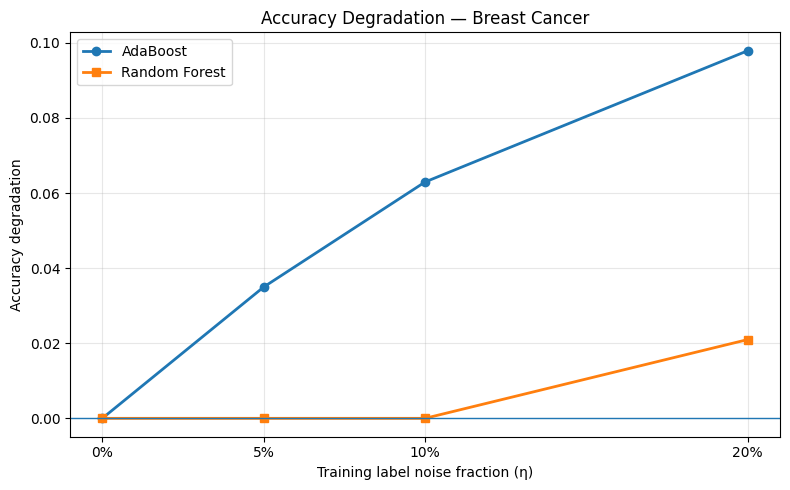

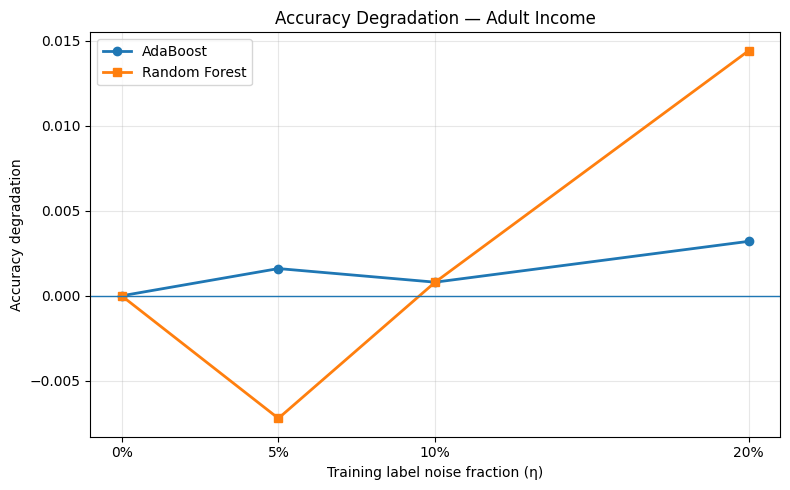

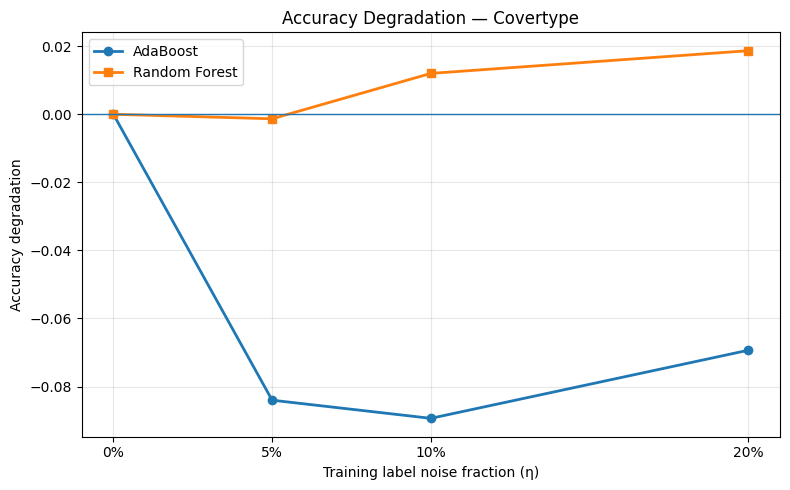

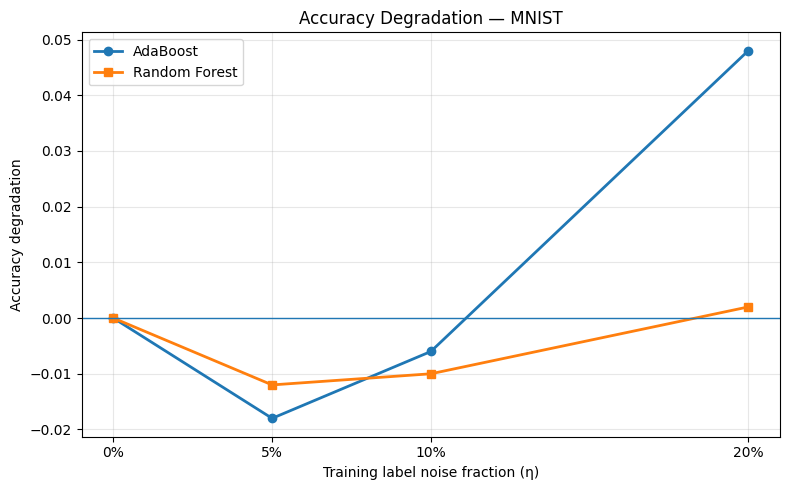

In [10]:
plot_degradation_curves(results_df)

In [19]:
sensitivity_summary = create_sensitivity_summary(results_df)

display(
    sensitivity_summary.style.format(
        {
            "adaboost_mean_degradation": "{:.4f}",
            "random_forest_mean_degradation": "{:.4f}",
        }
    )
)

,dataset,mean_adaboost_degradation,mean_random_forest_degradation,more_sensitive_model
0,Adult Income,0.001867,0.002667,Random Forest
1,Breast Cancer,0.065268,0.006993,AdaBoost
2,Covertype,-0.080889,0.009778,Random Forest
3,MNIST,0.008000,-0.006667,AdaBoost


## Sensitivity and Bias–Variance Discussion

On Breast Cancer, AdaBoost’s mean degradation was 0.0653, while Random Forest’s was 0.0070. Therefore, AdaBoost was clearly more sensitive.

On Adult Income, AdaBoost’s mean degradation was 0.0019 and Random Forest’s was 0.0027. Both models were stable, but Random Forest was slightly more sensitive.

On Covertype, AdaBoost’s mean degradation was -0.0809, while Random Forest’s was 0.0098. The negative value means AdaBoost performed better than its clean baseline for this fixed subset and seed; it does not prove that noise improves performance.

On MNIST, AdaBoost’s mean degradation was 0.0080, while Random Forest’s was -0.0067. AdaBoost was more sensitive, while Random Forest remained very stable.

Overall, Random Forest was more robust on Breast Cancer and MNIST. AdaBoost can be more sensitive because it increases the weights of misclassified samples and may focus on corrupted labels. Random Forest reduces the high variance of deep trees through bootstrap sampling, random feature selection, and majority voting.

